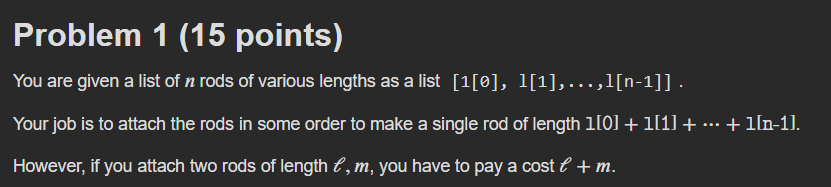
Hint: Think about the similarities between this problem and Huffman codes that you studied

In [27]:
import heapq

def findOptimalJoiningCost(lengths):
    # your code here
    heapq.heapify(lengths)
    total_count = 0
    while(len(lengths)>0):
        len1 = heapq.heappop(lengths)
        if(len(lengths)>0):
            len2 = heapq.heappop(lengths)
            total_count += (len1+len2)
            print(f'{total_count},{len1},{len2}')
            if(len(lengths)>0):
                heapq.heappush(lengths, len1+len2)
        else:
            total_count += len1
    
    assert(len(lengths)==0)
    return total_count

In [28]:
print('-- Test 1 --')
l1 = [1, 5, 2, 4, 3, 2]
c1 = findOptimalJoiningCost(l1)
print(c1)
assert c1 == 42


-- Test 1 --
3,1,2
8,2,3
15,3,4
25,5,5
42,7,10
42


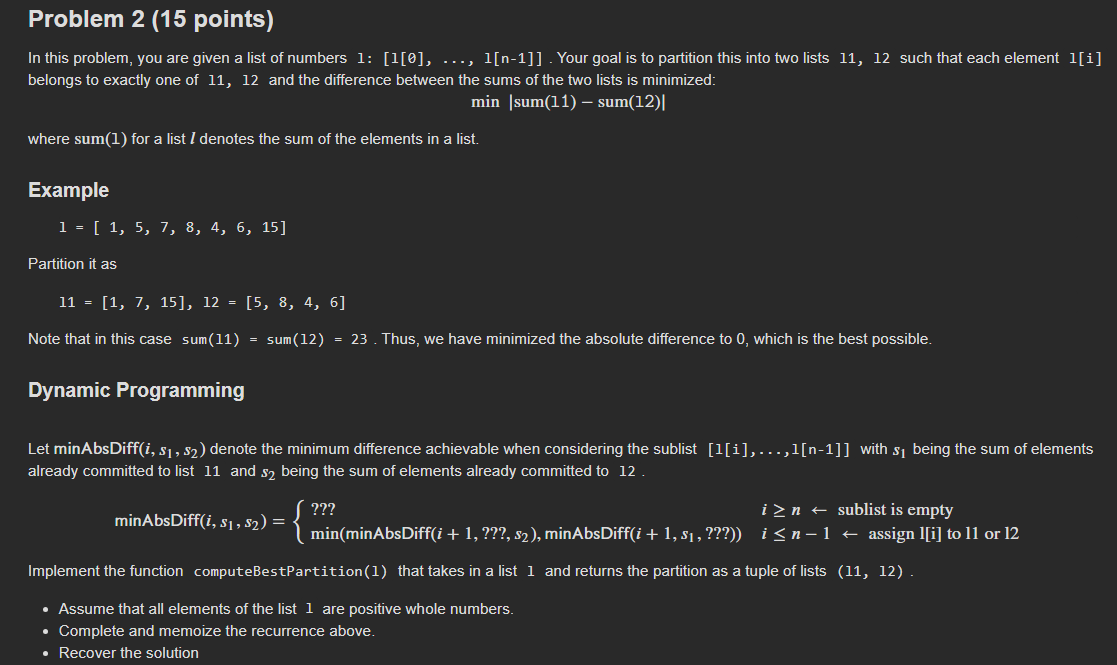

In [47]:
def computeBestPartition(l):
    n = len(l)
    assert n >= 1
    assert all(elt >= 1 and elt== int(elt) for elt in l)
    # your code here
    (val,out1,out2) = DP(0,frozenset(),frozenset(),l,{})
    return (out1,out2)

cache = {}

def DP(i,s1,s2,l,cache):
    key = frozenset({s1,s2})
    if key in cache:
        return cache[key]
    if(i>=len(l)):
        return (abs(sum(s1)-sum(s2)),s1,s2)
    (val1,o1,o2) = DP(i+1,s1.union(frozenset({l[i]})),s2,l,cache)
    (val2,o3,o4) = DP(i+1,s1,s2.union(frozenset({l[i]})),l,cache)
    if min(val1,val2) == val1:
        cache[key] = (val1,o1,o2)
        return (val1,o1,o2)
    else:
        cache[key] = (val2,o3,o4)
        return (val2,o3,o4)

In [51]:
def checkIfPartition(l, l1, l2):
    assert all((elt in l1 and elt not in l2) or (elt in l2 and elt not in l1) for elt in l)
    assert all(elt in l for elt in l1)
    assert all(elt in l for elt in l2)

print('-- Test 1 --')
l = [ 1, 5, 7, 8, 4, 6, 15]
(l1, l2) = computeBestPartition(l)
print(l1, l2, sum(l1), sum(l2))
assert sum(l1) == sum(l2)
checkIfPartition(l, l1, l2)
print('passed.')
print('-- Test 2 --')
l = [1, 10, 14, 16, 19, 22, 29 ,41,  15, 18]
(l1, l2) = computeBestPartition(l)
print(l1, l2, sum(l1), sum(l2))
assert abs(sum(l1) - sum(l2)) <= 1
checkIfPartition(l, l1, l2)
print('passed.')
print('-- Test 3 --')
l = [5, 16, 21, 13, 15, 18, 19, 14, 12, 2, 4]
(l1, l2) = computeBestPartition(l)
print(l1, l2, sum(l1), sum(l2))
assert abs(sum(l1) - sum(l2)) <= 1
checkIfPartition(l, l1, l2)
print('passed.')
print('-- Test 4 --')
l = [4, 15, 17, 12, 19, 20, 21,  29, 18, 14,  13, 11, 8, 5, 6]
(l1, l2) = computeBestPartition(l)
print(l1, l2, sum(l1), sum(l2))
assert abs(sum(l1) - sum(l2)) <= 0
checkIfPartition(l, l1, l2)
print('passed.')
print('All tests passed: 15 points!')

-- Test 1 --


frozenset({1, 4, 5, 6, 7}) frozenset({8, 15}) 23 23
passed.
-- Test 2 --
frozenset({16, 1, 18, 19, 10, 14, 15}) frozenset({41, 29, 22}) 93 92
passed.
-- Test 3 --
frozenset({16, 21, 5, 13, 15}) frozenset({18, 19, 2, 4, 12, 14}) 70 69
passed.
-- Test 4 --
frozenset({17, 19, 4, 20, 5, 12, 14, 15}) frozenset({29, 18, 21, 6, 8, 11, 13}) 106 106
passed.
All tests passed: 15 points!


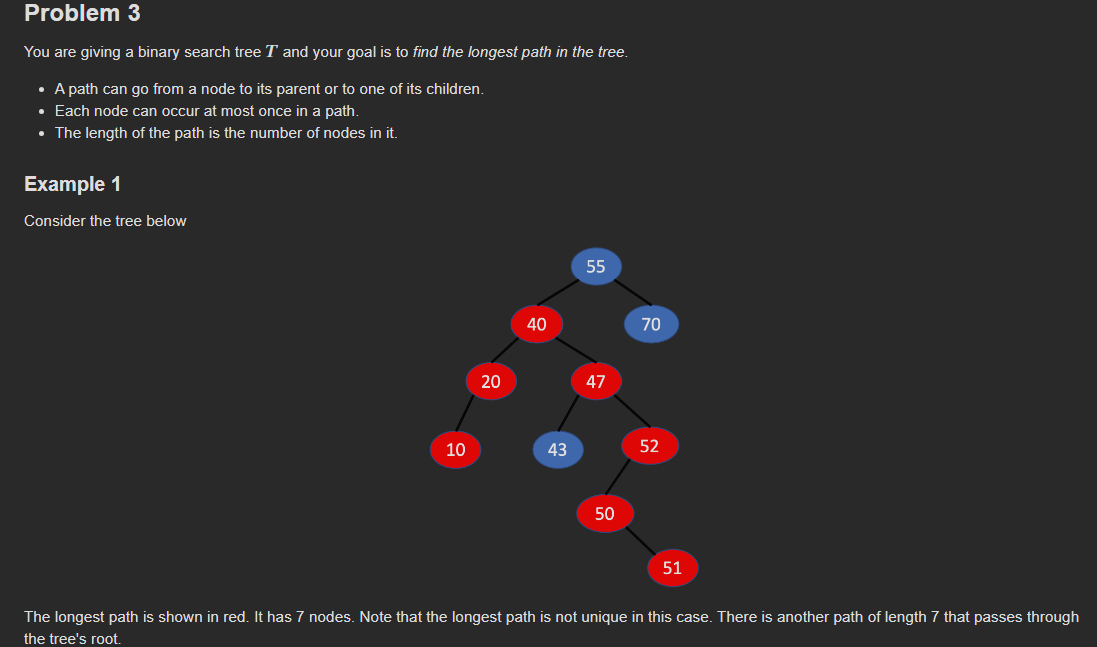
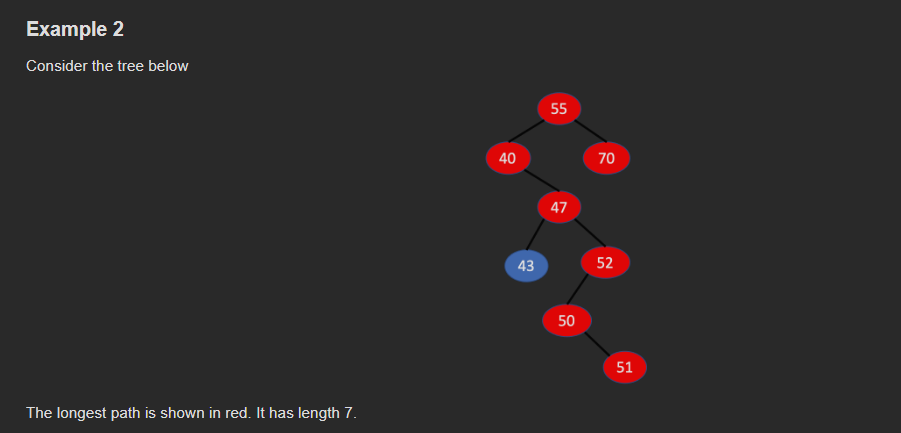
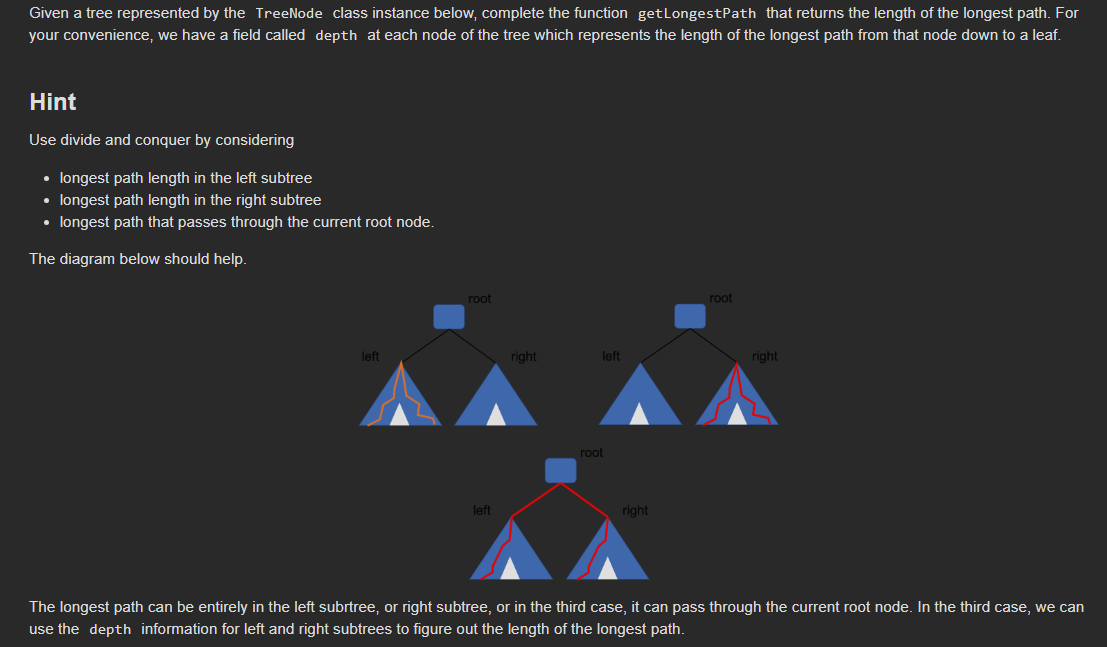

In [1]:
class TreeNode:
    def __init__(self, key, parent_node=None):
        # this is the key at the current node
        self.key = key
        # store parent node information
        self.parent = parent_node
        # left and right children
        self.left = None
        self.right = None
        # depth
        self.depth = 1
    
    def is_root(self):
        return self.parent_node == None
    
    def insert(self, new_key):
        key = self.key
        if new_key == key:
            print(f'Already inserted key {key}. Ignoring')
        elif new_key < key:
            if self.left == None:
                new_node = TreeNode(new_key, self)
                self.left = new_node
            else:
                self.left.insert(new_key)
        else: 
            assert new_key > key
            if self.right == None:
                new_node = TreeNode(new_key, self)
                self.right = new_node
            else: 
                self.right.insert(new_key)
        #update the depth
        left_depth = self.left.depth if self.left != None else 0
        right_depth = self.right.depth if self.right != None else 0
        self.depth = max(left_depth, right_depth) + 1

In [52]:

def getLongestPathLength(rootNode):
    # rootNode is an instance of the TreeNode class
    # The function must return the longest path length
    # your code here
    global max_route
    if(rootNode.left == None and rootNode.right == None): #leaf node
        assert(rootNode.depth ==1)
        return rootNode.depth

    left_longest = 0
    right_longest = 0
    middle_longest = 0
    if(rootNode.left != None):
        left_longest = getLongestPathLength(rootNode.left)
    if(rootNode.right != None):
        right_longest = getLongestPathLength(rootNode.right)
    if(rootNode.left != None and rootNode.right != None):    
        middle_longest = rootNode.left.depth + rootNode.right.depth + 1
    return max( left_longest, right_longest, middle_longest)

In [53]:
def make_tree(l):
    assert len(l) >= 1
    rootNode = TreeNode(l[0])
    for elt in l[1:]:
        rootNode.insert(elt)
    return rootNode

print('-- Test 1 --')
l = [55, 40, 70, 20, 47, 10, 43, 52, 50, 51]
r = make_tree(l)
path_len = getLongestPathLength(r)
print(path_len)
assert path_len == 7
print('passed')
print('-- Test 2 --')
l = [55, 40, 70, 47,  43, 52, 50, 51]
r = make_tree(l)
path_len = getLongestPathLength(r)
print(path_len)
assert path_len == 7
print('-- Test 3 --')
l = [26, 17, 41, 14, 21, 30, 47, 10, 16, 19, 23, 28, 38, 7, 12, 15, 20, 35, 39, 3]
r = make_tree(l)
path_len = getLongestPathLength(r)
print(path_len)
assert path_len == 10
print('-- Test 4--')
l = [7, 4, 18, 3, 6, 11, 19, 2, 9, 14, 22, 12, 17, 20, 21]
r = make_tree(l)
path_len = getLongestPathLength(r)
print(path_len)
assert path_len == 9
print('All Tests Passed: 15 points!')

-- Test 1 --
7
passed
-- Test 2 --
7
-- Test 3 --
10
-- Test 4--
9
All Tests Passed: 15 points!
